<a href="https://colab.research.google.com/github/jioring4351/hongong-ML-study/blob/main/Chapter2/2_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 데이터 전처리 하기
전 파트까지 하고 난 이후 문제

In [29]:
#생선 데이터 입력
fish_length = [25.4, 26.3, 26.5, 29.0, 29.0, 29.7, 29.7, 30.0, 30.0, 30.7, 31.0, 31.0,
                31.5, 32.0, 32.0, 32.0, 33.0, 33.0, 33.5, 33.5, 34.0, 34.0, 34.5, 35.0,
                35.0, 35.0, 35.0, 36.0, 36.0, 37.0, 38.5, 38.5, 39.5, 41.0, 41.0, 9.8,
                10.5, 10.6, 11.0, 11.2, 11.3, 11.8, 11.8, 12.0, 12.2, 12.4, 13.0, 14.3, 15.0]
fish_weight = [242.0, 290.0, 340.0, 363.0, 430.0, 450.0, 500.0, 390.0, 450.0, 500.0, 475.0, 500.0,
                500.0, 340.0, 600.0, 600.0, 700.0, 700.0, 610.0, 650.0, 575.0, 685.0, 620.0, 680.0,
                700.0, 725.0, 720.0, 714.0, 850.0, 1000.0, 920.0, 955.0, 925.0, 975.0, 950.0, 6.7,
                7.5, 7.0, 9.7, 9.8, 8.7, 10.0, 9.9, 9.8, 12.2, 13.4, 12.2, 19.7, 19.9]

In [30]:
import numpy as np

In [31]:
#column.stack() 으로 리스트 붙이기. 이렇게 하면 튜플로 전달되는ㄷ네 튜플은 리스트처럼 원소에 순서가 있지만 수정할수 없어지고 튜플을 사용하면함수로 전달한 값이 바뀌지 않는다는 것을 믿을 수 있기에 매개변수 값으로 많이 사용함
fish_data = np.column_stack((fish_length, fish_weight))

fish_data

array([[  25.4,  242. ],
       [  26.3,  290. ],
       [  26.5,  340. ],
       [  29. ,  363. ],
       [  29. ,  430. ],
       [  29.7,  450. ],
       [  29.7,  500. ],
       [  30. ,  390. ],
       [  30. ,  450. ],
       [  30.7,  500. ],
       [  31. ,  475. ],
       [  31. ,  500. ],
       [  31.5,  500. ],
       [  32. ,  340. ],
       [  32. ,  600. ],
       [  32. ,  600. ],
       [  33. ,  700. ],
       [  33. ,  700. ],
       [  33.5,  610. ],
       [  33.5,  650. ],
       [  34. ,  575. ],
       [  34. ,  685. ],
       [  34.5,  620. ],
       [  35. ,  680. ],
       [  35. ,  700. ],
       [  35. ,  725. ],
       [  35. ,  720. ],
       [  36. ,  714. ],
       [  36. ,  850. ],
       [  37. , 1000. ],
       [  38.5,  920. ],
       [  38.5,  955. ],
       [  39.5,  925. ],
       [  41. ,  975. ],
       [  41. ,  950. ],
       [   9.8,    6.7],
       [  10.5,    7.5],
       [  10.6,    7. ],
       [  11. ,    9.7],
       [  11.2,    9.8],


In [32]:
#concatenate() 메서드
fish_target = np.concatenate((np.ones(35), np.zeros(14)))
fish_target #1은 도미 0은 빙어

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

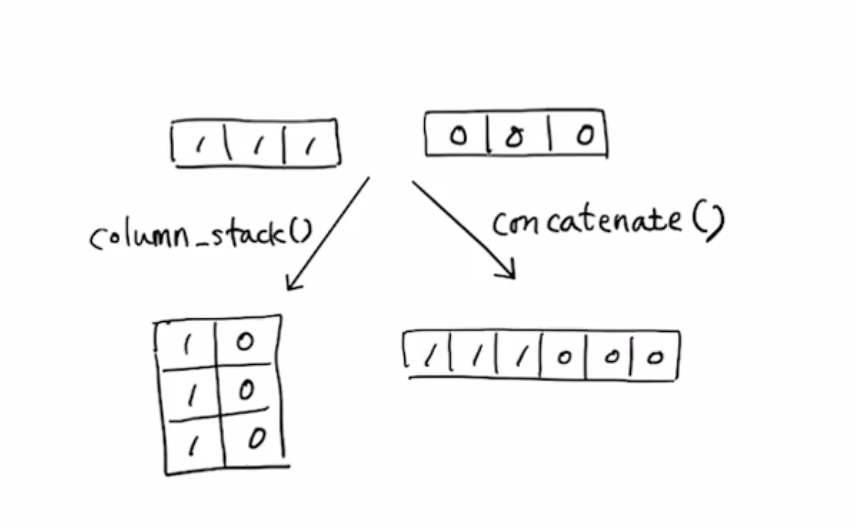

# 사이킷런으로 훈련 세트와 테스트 세트 나누기

In [33]:
from sklearn.model_selection import train_test_split

#알아서 랜덤하게 섞어줌. (동일한 방식대로 섞도록 seed를 줄 수 있음)
#stratify 를 쓰면 훈련세트와 테스트세트가 비율에 맞게 섞이도록 해줌.
#기본적으로 25%를 테스트 세트로 떼어냄
train_input, test_input, train_target, test_target = train_test_split(
    fish_data, fish_target, random_state=42)

수상한 도미 한마리

In [34]:
#k 최근접 이웃 사용해보기
from sklearn.neighbors import KNeighborsClassifier

kn = KNeighborsClassifier()
kn.fit(train_input, train_target)
kn.score(test_input, test_target)

1.0

In [35]:
#문제제기 된 예시. 도미값같이 만들었는데 빙어가 나옴. 왜그럴까?
print(kn.predict([[25,150]]))

[0.]


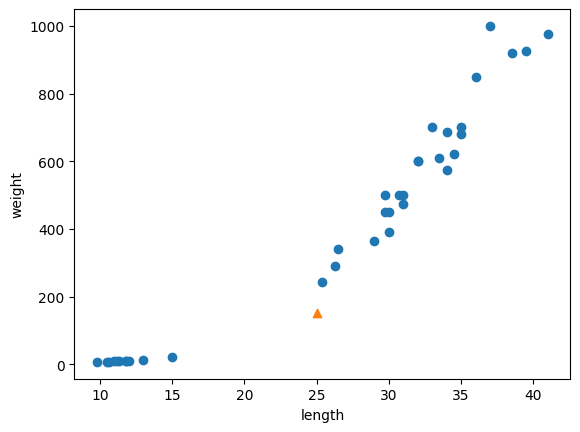

In [36]:
#k최근접 이웃은 주변 5개의 값을 보는데 그게 빙어가 많기 때문에 이렇게 나온 것.
from matplotlib import pyplot as plt

plt.scatter(train_input[:,0], train_input[:,1])
plt.scatter(25, 150, marker='^')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

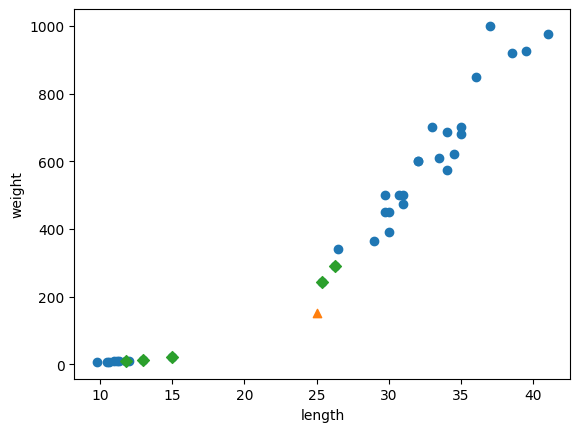

In [37]:
#산점도로 더 자세히 확인해보기
distance, indexes = kn.kneighbors([[25,150]])

plt.scatter(train_input[:,0], train_input[:,1])
plt.scatter(25, 150, marker='^')
plt.scatter(train_input[indexes,0], train_input[indexes,1], marker='D')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

# 기준맞추기
x축과 y축의 단위가 다르기 때문에 가까운 데이터를 고른 것이다

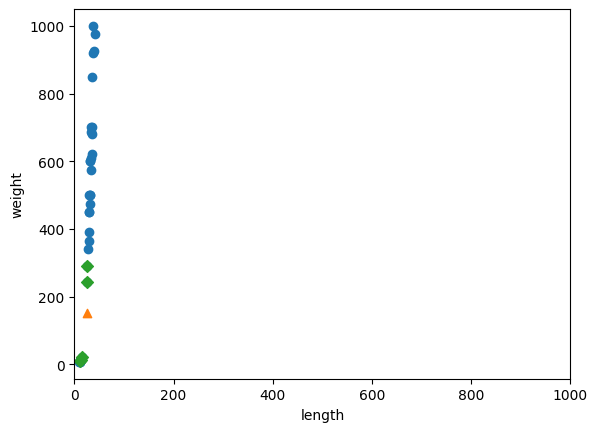

In [38]:
#x축의 값의 기준도 맞추기
plt.scatter(train_input[:,0], train_input[:,1])
plt.scatter(25, 150, marker='^')
plt.scatter(train_input[indexes,0], train_input[indexes,1], marker='D')
plt.xlim((0, 1000))
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

이런 이유때문에 데이터 전처리가 매우 중요함

#표준점수로 바꾸기(표준화)
가장 널리 사용하는 전처리 방법 중 하나.
각 특성값이 평균에서 표준편차의 몇 배만큼 떨어져 있는지 나타내줌.

In [39]:
#numpy에는 편하게 평균을 구할 수 있는 메서드가 존재
mean = np.mean(train_input, axis = 0)
std = np.std(train_input, axis = 0)

print(mean, std)

[ 26.175      418.08888889] [ 10.21073441 321.67847023]


In [40]:
#표준점수로 변환하기(브로드캐스팅 이용)
train_scaled = (train_input - mean) / std

#전처리 데이터(표준점수)로 다시 모델 훈련하기

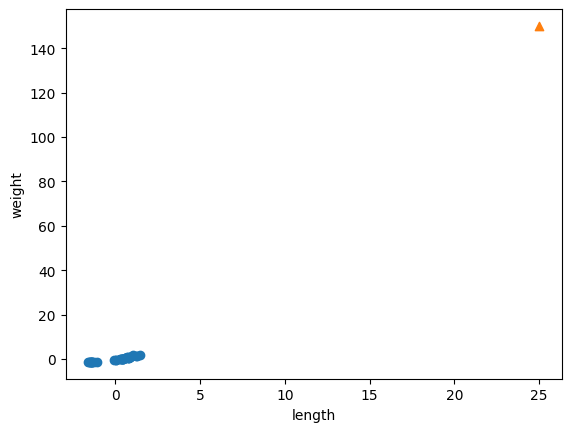

In [41]:
plt.scatter(train_scaled[:,0], train_scaled[:,1])
plt.scatter(25, 150, marker='^')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

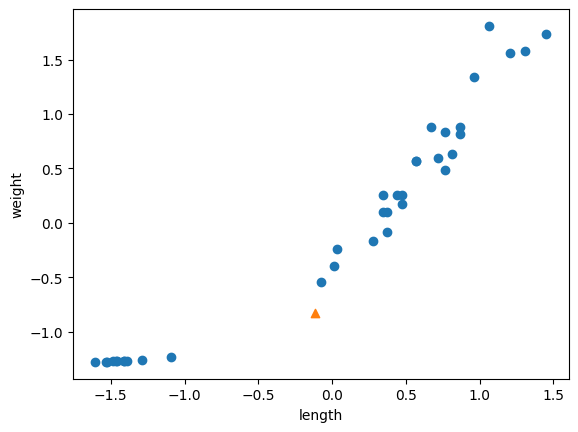

In [42]:
#샘플(25, 150)도 동일 비율로 만들기
new = ([25, 150] - mean) / std

plt.scatter(train_scaled[:,0], train_scaled[:,1])
plt.scatter(new[0], new[1], marker='^')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

In [43]:
#test세트도 변환 후 훈련시키기
kn.fit(train_scaled, train_target)

test_scaled = (test_input - mean) / std
kn.score(test_scaled, test_target)

1.0

In [44]:
print(kn.predict([new]))

[1.]


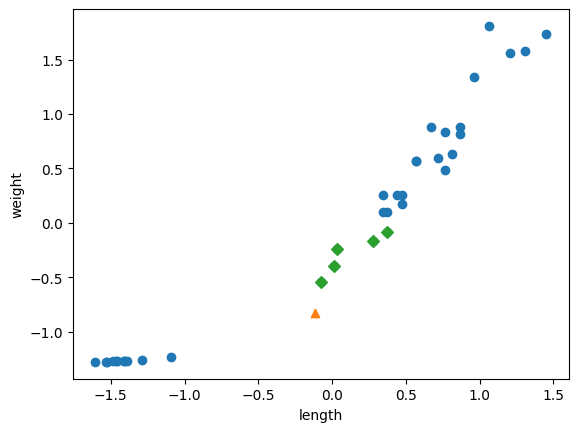

In [45]:
#new 주변의 5개 보기
distances, indexes = kn.kneighbors([new])

plt.scatter(train_scaled[:,0], train_scaled[:,1])
plt.scatter(new[0],new[1], marker = '^')
plt.scatter(train_scaled[indexes, 0], train_scaled[indexes, 1], marker = 'D')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()